In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel('Building_Energy_Consumption_Data.xlsx')

In [ ]:
df.head()

,Building_ID,Year,Building_Type,Floor_Area (m²),Energy_Consumption (kWh),Occupancy_Rate (%),Region,Energy_Score,Energy_Cost (IDR),Province,Average_Temp,Energy_Consumption_AC (kWh),Energy_Consumption_Lighting (kWh)
0,1,2022,Industrial,4941,17874,50.91,Urban,83,229490100.0,Jawa Barat,24⁰ C,14300,3574
1,2,2023,Commercial,3677,37711,54.72,Urban,17,244641180.0,Jawa Barat,20⁰ C,30169,7542
2,3,2020,Commercial,1413,10539,84.15,Rural,85,256921980.0,Jawa Barat,22⁰ C,8432,2107
3,4,2022,Commercial,2031,58351,NaN,Urban,78,150017140.0,Jawa Barat,18⁰ C,46681,11670
4,5,2022,Commercial,1713,66267,65.95,Suburban,73,147403340.0,Jawa Barat,18⁰ C,53014,13253


In [ ]:
missing_data = df.isna().sum()

print(missing_data)

Building_ID                          0
Year                                 0
Building_Type                        0
Floor_Area (m²)                      0
Energy_Consumption (kWh)             0
Occupancy_Rate (%)                   8
Region                               0
Energy_Score                         0
Energy_Cost (IDR)                    0
Province                             0
Average_Temp                         0
Energy_Consumption_AC (kWh)          0
Energy_Consumption_Lighting (kWh)    0
dtype: int64


In [ ]:
df

,Building_ID,Year,Building_Type,Floor_Area (m²),Energy_Consumption (kWh),Occupancy_Rate (%),Region,Energy_Score,Energy_Cost (IDR),Province,Average_Temp,Energy_Consumption_AC (kWh),Energy_Consumption_Lighting (kWh)
0,1,2022,Industrial,4941,17874,50.91,Urban,83,229490100.0,Jawa Barat,24⁰ C,14300,3574
1,2,2023,Commercial,3677,37711,54.72,Urban,17,244641180.0,Jawa Barat,20⁰ C,30169,7542
2,3,2020,Commercial,1413,10539,84.15,Rural,85,256921980.0,Jawa Barat,22⁰ C,8432,2107
3,4,2022,Commercial,2031,58351,NaN,Urban,78,150017140.0,Jawa Barat,18⁰ C,46681,11670
4,5,2022,Commercial,1713,66267,65.95,Suburban,73,147403340.0,Jawa Barat,18⁰ C,53014,13253
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,2021,Residential,4549,83069,64.29,Urban,50,269676680.0,JawaTimur,20⁰ C,41535,41534
96,97,2021,Commercial,3241,59748,93.43,Urban,61,254823240.0,JawaTimur,20⁰ C,47799,11949
97,98,2023,Residential,1746,10801,61.18,Urban,51,66080420.0,Other,22⁰ C,5401,5400
98,99,2021,Residential,4041,24190,98.16,Suburban,19,32450040.0,Other,22⁰ C,12095,12095


In [ ]:
df_numeric = df.drop(columns=['Building_ID', 'Year', 'Building_Type', 'Region', 'Province'])
df_numeric.head()

,Floor_Area (m²),Energy_Consumption (kWh),Occupancy_Rate (%),Energy_Score,Energy_Cost (IDR),Average_Temp,Energy_Consumption_AC (kWh),Energy_Consumption_Lighting (kWh)
0,4941,17874,50.91,83,229490100.0,24⁰ C,14300,3574
1,3677,37711,54.72,17,244641180.0,20⁰ C,30169,7542
2,1413,10539,84.15,85,256921980.0,22⁰ C,8432,2107
3,2031,58351,NaN,78,150017140.0,18⁰ C,46681,11670
4,1713,66267,65.95,73,147403340.0,18⁰ C,53014,13253


In [ ]:
import pandas as pd
import re

# Fungsi untuk konversi Fahrenheit ke Celsius
def fahrenheit_to_celsius(f):
    return (f - 32) * 5.0 / 9.0

# Fungsi untuk membersihkan dan mengubah semua suhu ke Celsius dalam bentuk numerik
def convert_temp(temp):
    # Mendeteksi apakah suhu dalam Fahrenheit atau Celsius
    if 'F' in temp:
        # Ekstrak nilai numerik suhu dalam Fahrenheit
        f_value = float(re.findall(r'\d+', temp)[0])
        # Konversi ke Celsius
        c_value = fahrenheit_to_celsius(f_value)
        return round(c_value, 1)  # Mengembalikan nilai numerik hasil konversi ke Celsius
    elif 'C' in temp:
        # Ekstrak nilai numerik suhu dalam Celsius
        c_value = float(re.findall(r'\d+', temp)[0])
        return c_value  # Mengembalikan nilai numerik Celsius
    else:
        return None  # Mengembalikan None jika format tidak dikenal

# Terapkan konversi ke kolom 'Average_Temp' dan simpan sebagai angka
df_numeric['Average_Temp'] = df_numeric['Average_Temp'].apply(convert_temp)

df_numeric.head()


,Floor_Area (m²),Energy_Consumption (kWh),Occupancy_Rate (%),Energy_Score,Energy_Cost (IDR),Average_Temp,Energy_Consumption_AC (kWh),Energy_Consumption_Lighting (kWh)
0,4941,17874,50.91,83,229490100.0,24.0,14300,3574
1,3677,37711,54.72,17,244641180.0,20.0,30169,7542
2,1413,10539,84.15,85,256921980.0,22.0,8432,2107
3,2031,58351,NaN,78,150017140.0,18.0,46681,11670
4,1713,66267,65.95,73,147403340.0,18.0,53014,13253


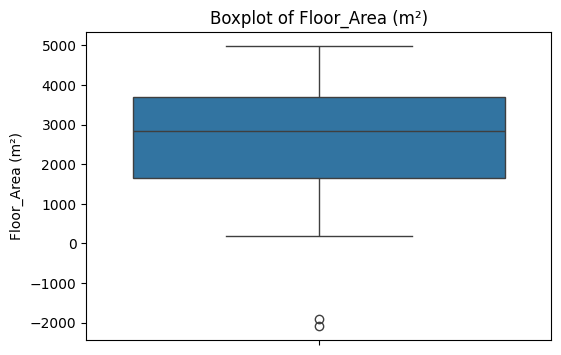

Number of outliers for Floor_Area (m²): 2
Outliers for Floor_Area (m²):
6    -2088
25   -1903
Name: Floor_Area (m²), dtype: int64


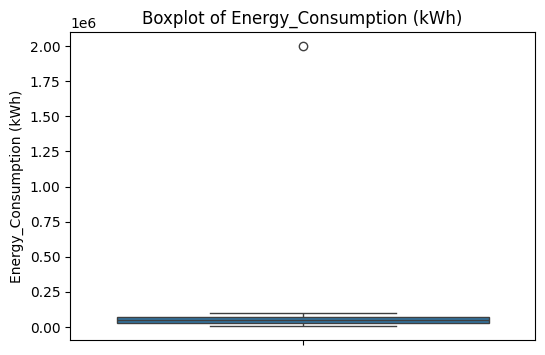

Number of outliers for Energy_Consumption (kWh): 1
Outliers for Energy_Consumption (kWh):
82    2000000
Name: Energy_Consumption (kWh), dtype: int64


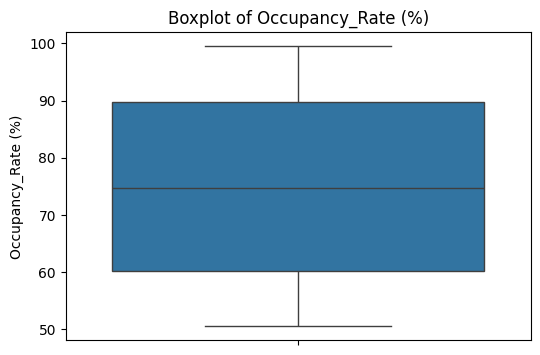

Number of outliers for Occupancy_Rate (%): 0
No outliers detected for Occupancy_Rate (%).


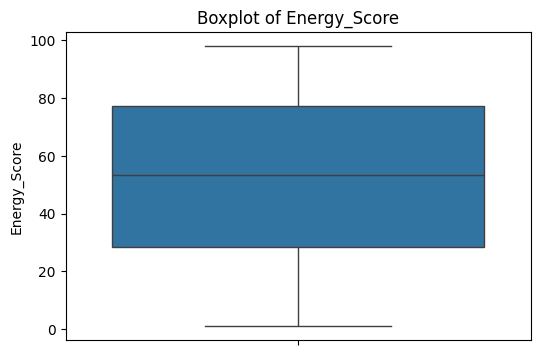

Number of outliers for Energy_Score: 0
No outliers detected for Energy_Score.


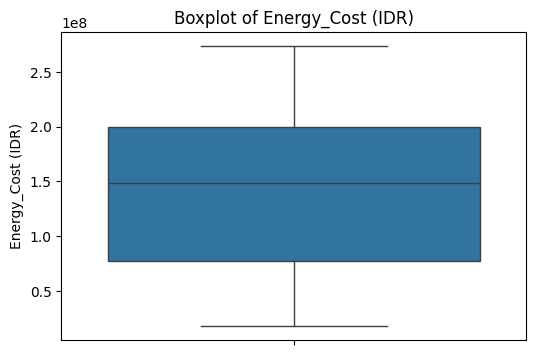

Number of outliers for Energy_Cost (IDR): 0
No outliers detected for Energy_Cost (IDR).


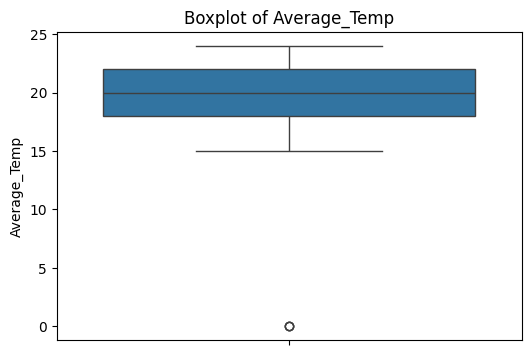

Number of outliers for Average_Temp: 3
Outliers for Average_Temp:
11    0.0
32    0.0
46    0.0
Name: Average_Temp, dtype: float64


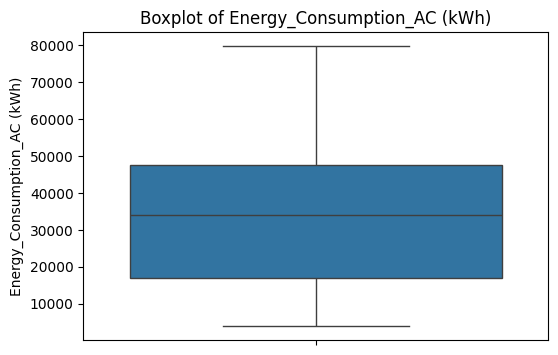

Number of outliers for Energy_Consumption_AC (kWh): 0
No outliers detected for Energy_Consumption_AC (kWh).


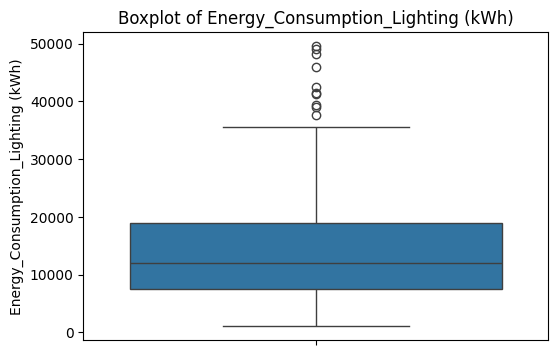

Number of outliers for Energy_Consumption_Lighting (kWh): 10
Outliers for Energy_Consumption_Lighting (kWh):
13    41252
17    49589
21    48206
22    45915
28    37635
36    42454
50    49089
55    39372
84    38995
95    41534
Name: Energy_Consumption_Lighting (kWh), dtype: int64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fungsi untuk mendeteksi dan menampilkan outlier
def detect_outliers(column_data):
    Q1 = column_data.quantile(0.25)
    Q3 = column_data.quantile(0.75)
    IQR = Q3 - Q1

    # Batas bawah dan atas untuk outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menemukan outlier
    outliers = column_data[(column_data < lower_bound) | (column_data > upper_bound)]
    return outliers

# Melakukan plotting boxplot dan menampilkan outlier untuk setiap kolom numerik
for column in df_numeric.columns:
    plt.figure(figsize=(6, 4))

    # Membuat boxplot
    sns.boxplot(y=df_numeric[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

    # Menemukan outlier untuk kolom saat ini
    outliers = detect_outliers(df_numeric[column])

    # Menampilkan jumlah outlier (jika ada)
    num_outliers = len(outliers)
    print(f"Number of outliers for {column}: {num_outliers}")

    # Menampilkan daftar outliers jika ada
    if num_outliers > 0:
        print(f"Outliers for {column}:")
        print(outliers)
    else:
        print(f"No outliers detected for {column}.")


In [ ]:
import pandas as pd

# Mengetahui list kolom dari DataFrame
list_kolom = df_numeric.columns.tolist()

# Cetak list kolom
print(list_kolom)


['Floor_Area (m²)', 'Energy_Consumption (kWh)', 'Occupancy_Rate (%)', 'Energy_Score', 'Energy_Cost (IDR)', 'Average_Temp', 'Energy_Consumption_AC (kWh)', 'Energy_Consumption_Lighting (kWh)']


In [ ]:
# Pilih kolom yang ingin direplace di data1 dengan kolom dari data2
kolom_replace = ['Floor_Area (m²)', 'Energy_Consumption (kWh)', 'Occupancy_Rate (%)',
                 'Energy_Score', 'Energy_Cost (IDR)', 'Average_Temp', 'Energy_Consumption_AC (kWh)',
                 'Energy_Consumption_Lighting (kWh)']  # Contoh: kolom A dan B akan direplace

# Replace kolom di data1 dengan kolom dari data2
df[kolom_replace] = df_numeric[kolom_replace]

df


,Building_ID,Year,Building_Type,Floor_Area (m²),Energy_Consumption (kWh),Occupancy_Rate (%),Region,Energy_Score,Energy_Cost (IDR),Province,Average_Temp,Energy_Consumption_AC (kWh),Energy_Consumption_Lighting (kWh)
0,1,2022,Industrial,4941,17874,50.91,Urban,83,229490100.0,Jawa Barat,24.0,14300,3574
1,2,2023,Commercial,3677,37711,54.72,Urban,17,244641180.0,Jawa Barat,20.0,30169,7542
2,3,2020,Commercial,1413,10539,84.15,Rural,85,256921980.0,Jawa Barat,22.0,8432,2107
3,4,2022,Commercial,2031,58351,NaN,Urban,78,150017140.0,Jawa Barat,18.0,46681,11670
4,5,2022,Commercial,1713,66267,65.95,Suburban,73,147403340.0,Jawa Barat,18.0,53014,13253
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,2021,Residential,4549,83069,64.29,Urban,50,269676680.0,JawaTimur,20.0,41535,41534
96,97,2021,Commercial,3241,59748,93.43,Urban,61,254823240.0,JawaTimur,20.0,47799,11949
97,98,2023,Residential,1746,10801,61.18,Urban,51,66080420.0,Other,22.0,5401,5400
98,99,2021,Residential,4041,24190,98.16,Suburban,19,32450040.0,Other,22.0,12095,12095


In [ ]:
df.head()

,Building_ID,Year,Building_Type,Floor_Area (m²),Energy_Consumption (kWh),Occupancy_Rate (%),Region,Energy_Score,Energy_Cost (IDR),Province,Average_Temp,Energy_Consumption_AC (kWh),Energy_Consumption_Lighting (kWh)
0,1,2022,Industrial,4941,17874,50.91,Urban,83,229490100.0,Jawa Barat,24.0,14300,3574
1,2,2023,Commercial,3677,37711,54.72,Urban,17,244641180.0,Jawa Barat,20.0,30169,7542
2,3,2020,Commercial,1413,10539,84.15,Rural,85,256921980.0,Jawa Barat,22.0,8432,2107
3,4,2022,Commercial,2031,58351,NaN,Urban,78,150017140.0,Jawa Barat,18.0,46681,11670
4,5,2022,Commercial,1713,66267,65.95,Suburban,73,147403340.0,Jawa Barat,18.0,53014,13253


In [ ]:
# Mengisi nilai kosong pada kolom 'A' dengan rata-rata kolom 'A'
df['Occupancy_Rate (%)'] = df['Occupancy_Rate (%)'].fillna(df['Occupancy_Rate (%)'].mean())

In [ ]:
import pandas as pd

def ganti_outlier(df, kolom, metode='mean'):
    """
    Fungsi untuk mengganti outlier pada kolom tertentu dengan mean, median, atau modus.

    Args:
    df (pd.DataFrame): DataFrame yang akan diolah.
    kolom (str): Nama kolom yang ingin diolah.
    metode (str): Metode untuk mengganti outlier, bisa 'mean', 'median', atau 'mode'.

    Returns:
    pd.DataFrame: DataFrame dengan outlier pada kolom yang dipilih sudah diganti.
    """
    # Hitung Q1 (kuartil pertama) dan Q3 (kuartil ketiga)
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)

    # Hitung IQR (Interquartile Range)
    IQR = Q3 - Q1

    # Tentukan batas bawah dan batas atas untuk mendeteksi outlier
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    # Tentukan metode pengganti (mean, median, atau mode)
    if metode == 'mean':
        nilai_pengganti = df[kolom].mean()
    elif metode == 'median':
        nilai_pengganti = df[kolom].median()
    elif metode == 'mode':
        nilai_pengganti = df[kolom].mode()[0]  # Modus bisa ada beberapa, ambil yang pertama
    else:
        raise ValueError("Metode tidak valid. Pilih salah satu: 'mean', 'median', atau 'mode'.")

    # Deteksi dan ganti outlier dengan nilai_pengganti
    df[kolom] = df[kolom].apply(lambda x: nilai_pengganti if (x < batas_bawah or x > batas_atas) else x)

    return df

# Contoh penggunaan

# Gantikan outlier pada kolom 'A' dengan median
df = ganti_outlier(df, kolom='Floor_Area (m²)', metode='median')
df = ganti_outlier(df, kolom='Energy_Consumption (kWh)', metode='mean')


In [ ]:
import pandas as pd

# Pilih kolom yang akan diproses (misalnya kolom 'Average_Temp')
kolom = 'Average_Temp'

# Hitung Q1 (Kuartil pertama) dan Q3 (Kuartil ketiga)
Q1 = df[kolom].quantile(0.25)
Q3 = df[kolom].quantile(0.75)

# Hitung IQR (Interquartile Range)
IQR = Q3 - Q1

# Tentukan batas bawah dan batas atas untuk mendeteksi outlier
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Ganti nilai di bawah batas_bawah dengan 15
df[kolom] = df[kolom].apply(lambda x: 15 if x < batas_bawah else x)



In [ ]:
from scipy import stats
import numpy as np

# Misalkan data di kolom 'A' memiliki nilai positif
kolom = 'Energy_Consumption_Lighting (kWh)'

# Lakukan transformasi Box-Cox (hanya bisa diterapkan pada data positif)
df[kolom], fitted_lambda = stats.boxcox(df[kolom])



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Building_ID                        100 non-null    int64  
 1   Year                               100 non-null    int64  
 2   Building_Type                      100 non-null    object 
 3   Floor_Area (m²)                    100 non-null    float64
 4   Energy_Consumption (kWh)           100 non-null    float64
 5   Occupancy_Rate (%)                 100 non-null    float64
 6   Region                             100 non-null    object 
 7   Energy_Score                       100 non-null    int64  
 8   Energy_Cost (IDR)                  100 non-null    float64
 9   Province                           100 non-null    object 
 10  Average_Temp                       100 non-null    float64
 11  Energy_Consumption_AC (kWh)        100 non-null    int64  


In [ ]:
df.head()

,Building_ID,Year,Building_Type,Floor_Area (m²),Energy_Consumption (kWh),Occupancy_Rate (%),Region,Energy_Score,Energy_Cost (IDR),Province,Average_Temp,Energy_Consumption_AC (kWh),Energy_Consumption_Lighting (kWh)
0,1,2022,Industrial,4941.0,17874.0,50.910000,Urban,83,229490100.0,Jawa Barat,24.0,14300,26.454036
1,2,2023,Commercial,3677.0,37711.0,54.720000,Urban,17,244641180.0,Jawa Barat,20.0,30169,32.625856
2,3,2020,Commercial,1413.0,10539.0,84.150000,Rural,85,256921980.0,Jawa Barat,22.0,8432,22.725272
3,4,2022,Commercial,2031.0,58351.0,75.063804,Urban,78,150017140.0,Jawa Barat,18.0,46681,36.796613
4,5,2022,Commercial,1713.0,66267.0,65.950000,Suburban,73,147403340.0,Jawa Barat,18.0,53014,38.098882


In [ ]:
# Menghitung jumlah kategori di kolom 'Kategori'
province_category = df['Province'].value_counts()

# Menampilkan hasil
print(province_category)

Province
Others         30
Jawa Timur     24
Jawa Barat     23
Jawa Tengah    18
Other           3
JawaTimur       2
Name: count, dtype: int64


In [ ]:
# Mengganti 'JawaTimur' dengan 'Jawa Timur' dan 'Other' dengan 'Others'
df['Province'] = df['Province'].replace({'JawaTimur': 'Jawa Timur', 'Other': 'Others'})


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Building_ID                        100 non-null    int64  
 1   Year                               100 non-null    int64  
 2   Building_Type                      100 non-null    object 
 3   Floor_Area (m²)                    100 non-null    float64
 4   Energy_Consumption (kWh)           100 non-null    float64
 5   Occupancy_Rate (%)                 100 non-null    float64
 6   Region                             100 non-null    object 
 7   Energy_Score                       100 non-null    int64  
 8   Energy_Cost (IDR)                  100 non-null    float64
 9   Province                           100 non-null    object 
 10  Average_Temp                       100 non-null    float64
 11  Energy_Consumption_AC (kWh)        100 non-null    int64  


In [ ]:
import pandas as pd

# Misalkan df adalah DataFrame yang berisi data Anda
# Menghitung rata-rata konsumsi energi per provinsi
average_energy_consumption = df.groupby('Province')['Energy_Consumption (kWh)'].mean()

# Menemukan provinsi dengan konsumsi energi rata-rata tertinggi
province_max_energy = average_energy_consumption.idxmax()
max_energy_value = average_energy_consumption.max()

# Menampilkan hasil
print(f"Provinsi dengan konsumsi energi rata-rata tertinggi: {province_max_energy}")
print(f"Konsumsi energi rata-rata: {max_energy_value} kWh")


Provinsi dengan konsumsi energi rata-rata tertinggi: Jawa Timur
Konsumsi energi rata-rata: 56136.230769230766 kWh


Profil konsumsi energi per meter persegi untuk setiap jenis bangunan:
Building_Type
Commercial     39.575176
Industrial     30.324238
Residential    24.613301
Name: Energy_Consumption_per_sqm, dtype: float64


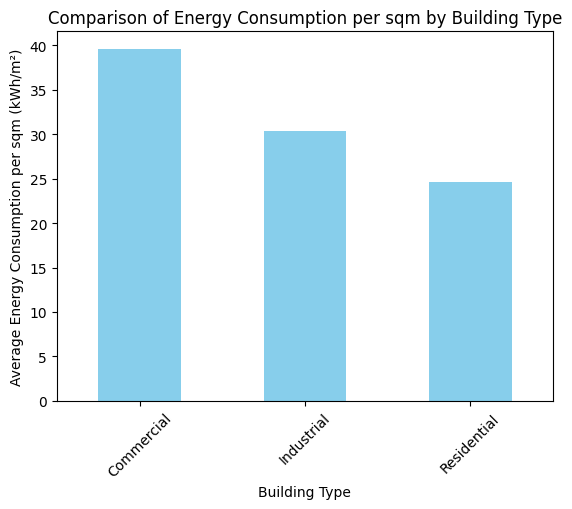

In [ ]:
import pandas as pd

# Menghitung konsumsi energi per meter persegi untuk setiap bangunan
df['Energy_Consumption_per_sqm'] = df['Energy_Consumption (kWh)'] / df['Floor_Area (m²)']

# Menghitung rata-rata konsumsi energi per meter persegi untuk setiap jenis bangunan
energy_profile = df.groupby('Building_Type')['Energy_Consumption_per_sqm'].mean()

# Menampilkan hasil
print("Profil konsumsi energi per meter persegi untuk setiap jenis bangunan:")
print(energy_profile)

# Jika ingin membandingkan secara visual, Anda bisa menggunakan bar plot:
import matplotlib.pyplot as plt

# Membuat bar plot untuk membandingkan konsumsi energi per sqm
energy_profile.plot(kind='bar', color='skyblue')
plt.title('Comparison of Energy Consumption per sqm by Building Type')
plt.xlabel('Building Type')
plt.ylabel('Average Energy Consumption per sqm (kWh/m²)')
plt.xticks(rotation=45)
plt.show()


In [ ]:
import pandas as pd

# Menghitung korelasi Pearson antara suhu rata-rata dan konsumsi energi
correlation = df['Average_Temp'].corr(df['Energy_Consumption (kWh)'])

# Menampilkan hasil korelasi
print(f"Korelasi antara suhu rata-rata dan konsumsi energi: {correlation}")


Korelasi antara suhu rata-rata dan konsumsi energi: -0.714311778154169


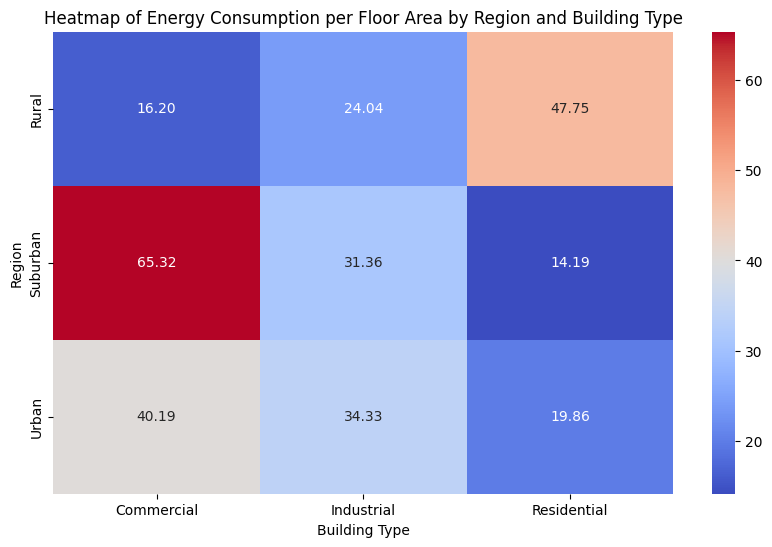

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Menghitung konsumsi energi per meter persegi
df['Energy_Consumption_per_sqm'] = df['Energy_Consumption (kWh)'] / df['Floor_Area (m²)']

# Menggunakan pivot_table untuk membentuk matriks berdasarkan Region dan Building_Type
heatmap_data = df.pivot_table(values='Energy_Consumption_per_sqm',
                              index='Region',
                              columns='Building_Type',
                              aggfunc='mean')

# Membuat heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f')

# Memberi judul dan label
plt.title('Heatmap of Energy Consumption per Floor Area by Region and Building Type')
plt.xlabel('Building Type')
plt.ylabel('Region')

# Menampilkan heatmap
plt.show()


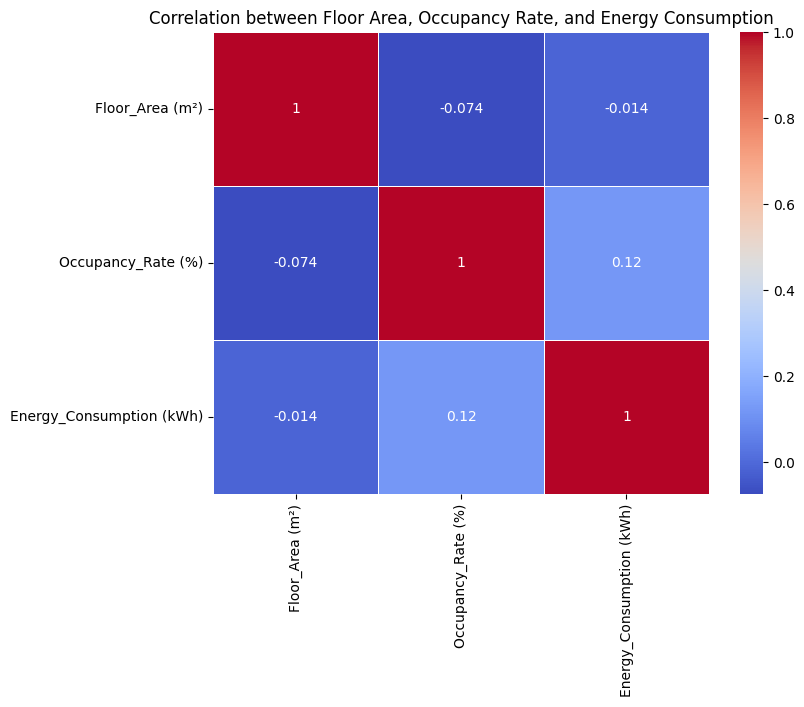

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Asumsikan dataframe Anda bernama df
# Jika belum ada, Anda bisa memuat data menggunakan pd.read_csv('nama_file.csv')

# Pilih kolom yang ingin dianalisis
columns_of_interest = ['Floor_Area (m²)', 'Occupancy_Rate (%)', 'Energy_Consumption (kWh)']

# Hitung matriks korelasi
correlation_matrix = df[columns_of_interest].corr()

# Plot heatmap korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

# Tambahkan judul
plt.title('Correlation between Floor Area, Occupancy Rate, and Energy Consumption')

# Tampilkan plot
plt.show()


<ipython-input-29-e9fb830a57fa>:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


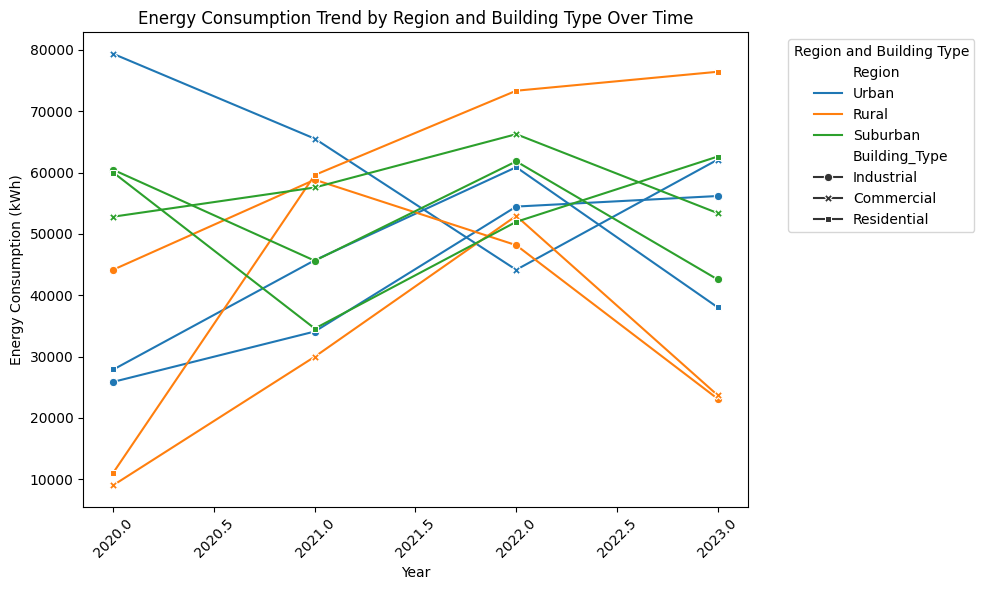

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Asumsikan dataframe Anda bernama df

# Plotting the trend of energy consumption over time
plt.figure(figsize=(10, 6))

# Membuat plot garis untuk tren konsumsi energi berdasarkan Region dan Building_Type tanpa background shading
sns.lineplot(
    data=df,
    x='Year',
    y='Energy_Consumption (kWh)',
    hue='Region',
    style='Building_Type',
    markers=True,
    dashes=False,
    ci=None  # Menghilangkan background confidence interval
)

# Memindahkan legend ke luar grafik agar tidak menutupi pola
plt.legend(title='Region and Building Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Menambahkan judul dan label sumbu
plt.title('Energy Consumption Trend by Region and Building Type Over Time')
plt.xlabel('Year')
plt.ylabel('Energy Consumption (kWh)')

# Tampilkan plot
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

plt.show()
